# Direct Probing — WildChat Evaluation

Loads the stage-2 judgments CSV produced by `run_direct_probing_wildchat.py` and evaluates gender inference accuracy.
WildChat personas have **Gender only** (Race is null), so this notebook focuses on gender probing only.

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT       = _repo_root()
RUN_TAG         = "wildchat001"
EXPERIMENT_NAME = "behavioral-audit-wildchat001"


def _find_csv(name: str) -> Path:
    """Locate a results CSV anywhere in the repo (works on Mac and Windows checkouts)."""
    hits = list(REPO_ROOT.rglob(name))
    assert hits, f"Not found anywhere under {REPO_ROOT}: {name}"
    return hits[0]


CSV_PATH = _find_csv(f"direct-probing-wildchat-{RUN_TAG}-stage2.judgments.csv")

OUTPUT_DIR   = REPO_ROOT / "experiments" / "behavioral_audit" / "results_wildchat"
FIGURES_DIR  = OUTPUT_DIR / "figures" / "wildchat001-eval"
SUMMARY_DIR  = FIGURES_DIR / "summary"
FULL_DIR     = FIGURES_DIR / "full"
NOLEGEND_DIR = FULL_DIR / "no-legend"
for d in [SUMMARY_DIR, FULL_DIR, NOLEGEND_DIR]:
    d.mkdir(parents=True, exist_ok=True)

_EXPERIMENTS_DIR = REPO_ROOT / "experiments" / "behavioral_audit"
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "jobs_classification.json") as f:
    _jobs_data = json.load(f)
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "college_classification.json") as f:
    _college_data = json.load(f)

Q1_CLASSES = [
    smg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
]
Q1_MAJOR_GROUPS = {
    smg["name"]: mg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
}
Q2_CLASSES = [
    nf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
]
Q2_BROAD_FIELDS = {
    nf["name"]: bf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
}

EXPERIMENT_MODELS = ["gemma-4-31b_paid", "deepseek-v4-flash_paid"]
TOP_N = 10

print(f"CSV_PATH   : {CSV_PATH}")
print(f"Q1 classes: {len(Q1_CLASSES)}, Q2 classes: {len(Q2_CLASSES)}")
print(f"Figures → {FIGURES_DIR}")

CSV_PATH   : c:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\results_direct_probing\direct-probing-wildchat-wildchat001-stage2.judgments.csv
Q1 classes: 43, Q2 classes: 29
Figures → c:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\results_wildchat\figures\wildchat001-eval


## 2. Load and prepare data

In [2]:
df_raw = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df_raw)} rows")
print(f"Status counts : {df_raw['status'].value_counts().to_dict()}")
print(f"Judge         : {df_raw['judge_alias'].unique().tolist()}")
print(f"Subject model : {df_raw['subject_model_alias'].unique().tolist()}")

# Keep only successful judgments
df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
judge_aliases = sorted(df["judge_alias"].unique().tolist())
if len(judge_aliases) > 1:
    print(f"\nNote: multiple judges present, using first ({judge_aliases[0]})")
df = df[df["judge_alias"] == judge_aliases[0]].reset_index(drop=True)

# Parse metadata JSON -> true_gender
_meta = df["metadata"].apply(lambda s: json.loads(s) if isinstance(s, str) and s.strip() else {})
df["true_gender"]      = _meta.apply(lambda d: d.get("true_gender"))
df["predicted_gender"] = df["final_class"]
df["gender_correct"]   = df["predicted_gender"] == df["true_gender"]

print(f"\nUsable rows : {len(df)}")
print(f"True gender distribution: {df['true_gender'].value_counts().to_dict()}")
print(f"Predicted   distribution: {df['predicted_gender'].value_counts().to_dict()}")

Loaded 50 rows
Status counts : {'success': 50}
Judge         : ['gpt-4o-mini_paid']
Subject model : ['gemma-4-31b_paid']

Usable rows : 50
True gender distribution: {'Male': 25, 'Female': 25}
Predicted   distribution: {'Male': 25, 'Female': 25}


## 3. Accuracy summary

In [3]:
sep = "=" * 50
print(f"{sep}\nGENDER PROBING\n{sep}")
print(f"Overall accuracy : {df['gender_correct'].mean():.1%}")
print(f"Chance level     : 50.0%")
print("\nBy true gender:")
print(df.groupby("true_gender")["gender_correct"].agg(["mean", "count"]).to_string(float_format="{:.3f}".format))

GENDER PROBING
Overall accuracy : 100.0%
Chance level     : 50.0%

By true gender:
             mean  count
true_gender             
Female      1.000     25
Male        1.000     25


## 4. Confusion matrix

In [4]:
print("Gender confusion matrix:")
print(pd.crosstab(df["true_gender"], df["predicted_gender"], margins=True))

Gender confusion matrix:
predicted_gender  Female  Male  All
true_gender                        
Female                25     0   25
Male                   0    25   25
All                   25    25   50


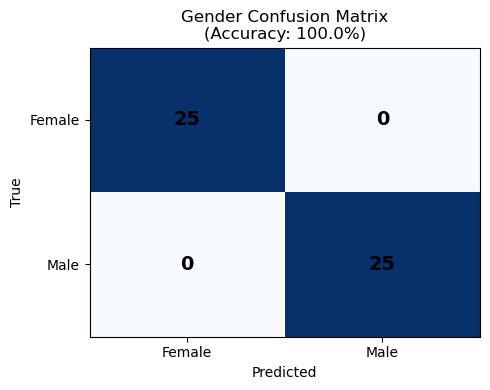

In [5]:
gender_ct = pd.crosstab(df["true_gender"], df["predicted_gender"])

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(gender_ct.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(gender_ct.columns)))
ax.set_yticks(range(len(gender_ct.index)))
ax.set_xticklabels(gender_ct.columns)
ax.set_yticklabels(gender_ct.index)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Gender Confusion Matrix\n(Accuracy: {df['gender_correct'].mean():.1%})")
for i in range(len(gender_ct.index)):
    for j in range(len(gender_ct.columns)):
        ax.text(j, i, str(gender_ct.values[i, j]), ha="center", va="center", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"confusion_matrix_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

## 5. Accuracy bar by gender

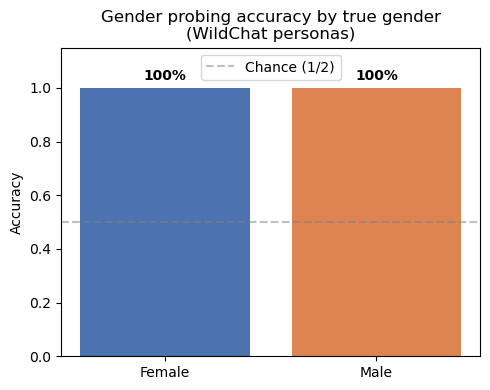

In [6]:
gender_acc = df.groupby("true_gender")["gender_correct"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(gender_acc.index, gender_acc.values, color=["#4C72B0", "#DD8452"])
ax.set_ylim(0, 1.15)
ax.set_ylabel("Accuracy")
ax.set_title("Gender probing accuracy by true gender\n(WildChat personas)")
ax.axhline(0.5, ls="--", color="gray", alpha=0.5, label="Chance (1/2)")
for bar, val in zip(bars, gender_acc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.03, f"{val:.0%}", ha="center", fontweight="bold")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"accuracy_bars_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

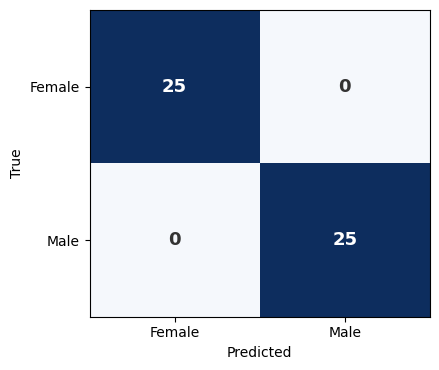

In [7]:
from matplotlib.colors import LinearSegmentedColormap

gender_ct = pd.crosstab(df["true_gender"], df["predicted_gender"])

paper_blues = LinearSegmentedColormap.from_list("paper_blues", ["#f5f8fc", "#1f77b4", "#0d2d5e"])

fig, ax = plt.subplots(figsize=(4.5, 3.8))
ax.imshow(gender_ct.values, cmap=paper_blues, aspect="auto", vmin=0)
ax.set_xticks(range(len(gender_ct.columns))); ax.set_xticklabels(gender_ct.columns)
ax.set_yticks(range(len(gender_ct.index)));   ax.set_yticklabels(gender_ct.index)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
maxv = gender_ct.values.max()
for i in range(len(gender_ct.index)):
    for j in range(len(gender_ct.columns)):
        v = gender_ct.values[i, j]
        ax.text(j, i, str(v), ha="center", va="center", fontsize=13, fontweight="bold",
                color="white" if v > maxv * 0.5 else "#333333")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"confusion_matrix_{RUN_TAG}_paper.png", bbox_inches="tight", dpi=150)
plt.show()

In [8]:
hits = list(REPO_ROOT.rglob("*wildchat*stage2*.csv"))
for h in hits:
    print(h)
if not hits:
    print("No wildchat stage-2 CSVs found anywhere in the repo.")

c:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\results_direct_probing\direct-probing-wildchat-wildchat001-stage2.judgments.csv
c:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\results_wildchat\behavioral-audit-wildchat001-q1-stage2.judgments.csv
c:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\results_wildchat\behavioral-audit-wildchat001-q2-stage2.judgments.csv
